In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install scanpy anndata scikit-misc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 82.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source

In [ ]:
import scanpy as sc
import anndata as ad
import os

In [ ]:
files = [
    "/content/drive/.../filtered_skin_donor1_data.h5ad",
    "/content/drive/.../filtered_skin_donor2_data.h5ad",
    "/content/drive/.../filtered_skin_donor3_data.h5ad",
    "/content/drive/.../filtered_skin_donor4_data.h5ad",
    "/content/drive/.../filtered_wound1_donor1_data.h5ad",
    "/content/drive/.../filtered_wound1_donor2_data.h5ad",
    "/content/drive/.../filtered_wound1_donor3_data.h5ad",
    "/content/drive/.../filtered_wound1_donor4_data.h5ad",
    "/content/drive/.../filtered_wound7_donor1_data.h5ad",
    "/content/drive/.../filtered_wound7_donor2_data.h5ad",
    "/content/drive/.../filtered_wound7_donor3_data.h5ad",
    "/content/drive/.../filtered_wound7_donor4_data.h5ad",
    "/content/drive/.../filtered_wound30_donor1_data.h5ad",
    "/content/drive/.../filtered_wound30_donor2_data.h5ad",
    "/content/drive/.../filtered_wound30_donor3_data.h5ad",
    "/content/drive/.../filtered_wound30_donor4_data.h5ad"
]

save_path = "/content/drive/.../final_dataset/bio_dataset.h5ad"


### Load datasets and add batch labels

In [ ]:
adatas = []

for f in files:

    adata = sc.read_h5ad(f)

    adata.var_names_make_unique()

    adata.obs["batch"] = (
        adata.obs["donor_id"].astype(str)
        + "_"
        + adata.obs["healing_stage"].astype(str)
    )

    adatas.append(adata)

print(f"Loaded {len(adatas)} datasets")

Loaded 16 datasets


### KEEP SHARED GENE SPACE

In [ ]:
shared_genes = set(adatas[0].var_names)

for adata in adatas[1:]:
    shared_genes = shared_genes.intersection(set(adata.var_names))

shared_genes = list(shared_genes)

adatas = [adata[:, shared_genes].copy() for adata in adatas]

print(f"Number of shared genes: {len(shared_genes)}")

Number of shared genes: 10500


### MERGE DATASETS

In [ ]:
adata = ad.concat(adatas, join="inner", index_unique="-")

### Exploration

In [ ]:
adata

AnnData object with n_obs × n_vars = 12251 × 10500
    obs: 'donor_id', 'healing_stage', 'healing_state', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'doublet_score', 'predicted_doublet', 'batch'

In [ ]:
adata.obs.head()

,donor_id,healing_stage,healing_state,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_MT,log1p_total_counts_MT,pct_counts_MT,doublet_score,predicted_doublet,batch
AAACAAGTATCTCCCA-1-0,D1,skin,0,787,6.669498,1450.0,7.280008,35.517241,45.793103,59.517241,80.206897,103.0,4.644391,7.103448,0.069965,False,D1_skin
AAACATTTCCCGGATT-1-0,D1,skin,0,429,6.063785,671.0,6.510258,37.257824,50.968703,65.871833,100.000000,21.0,3.091043,3.129657,0.053318,False,D1_skin
AAACCTAAGCAGCCGG-1-0,D1,skin,0,3527,8.168486,12961.0,9.469777,46.007253,51.971299,58.845768,68.513232,1943.0,7.572503,14.991127,0.044920,False,D1_skin
AAACCTCATGAAGTTG-1-0,D1,skin,0,1522,7.328437,3355.0,8.118505,27.451565,39.135618,51.147541,69.538003,132.0,4.890349,3.934426,0.063745,False,D1_skin
AAACGAGACGGTTGAT-1-0,D1,skin,0,637,6.458338,976.0,6.884487,30.327869,41.393443,55.225410,85.963115,38.0,3.663562,3.893442,0.069965,False,D1_skin


Class Balance

In [ ]:
print(adata.obs["healing_state"].value_counts())

Donor Distribution

In [ ]:
print(adata.obs["donor_id"].value_counts())

Batch Distribution

In [ ]:
print(adata.obs["batch"].value_counts())

Global QC Visualization

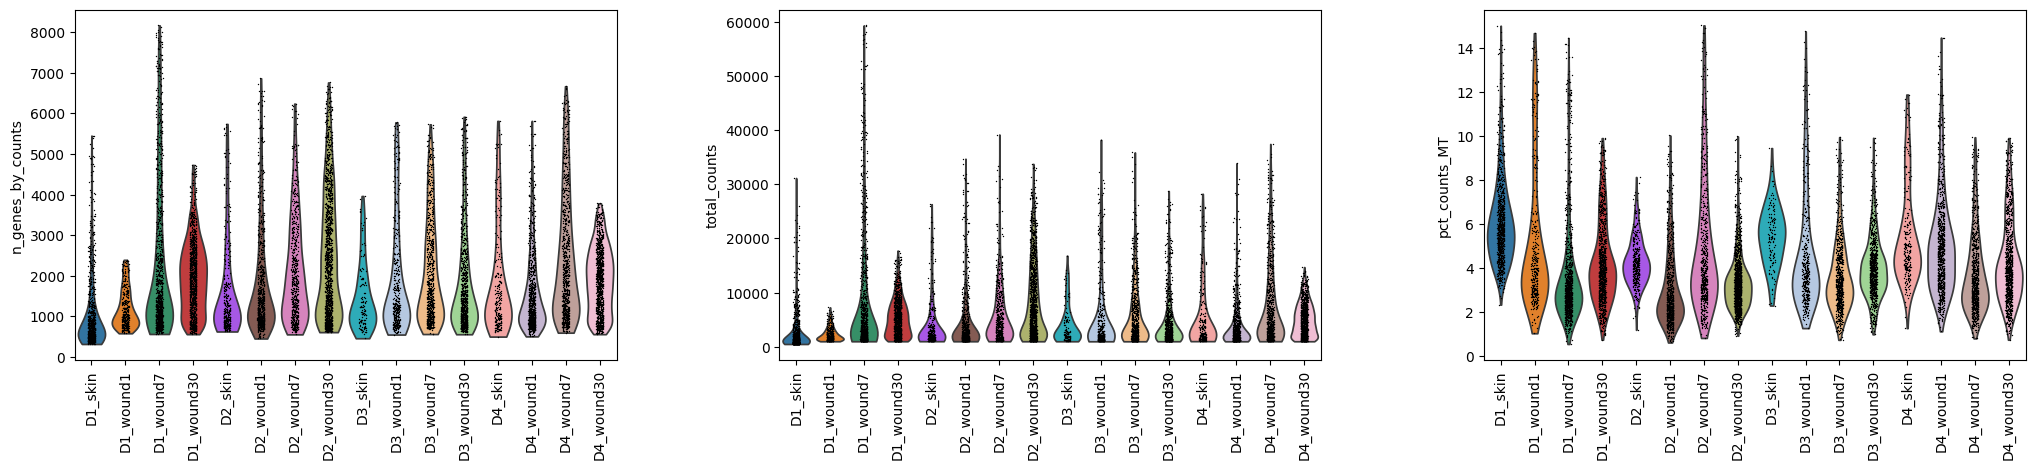

In [ ]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_MT"],
    groupby="batch",
    rotation=90,
    multi_panel=True
)

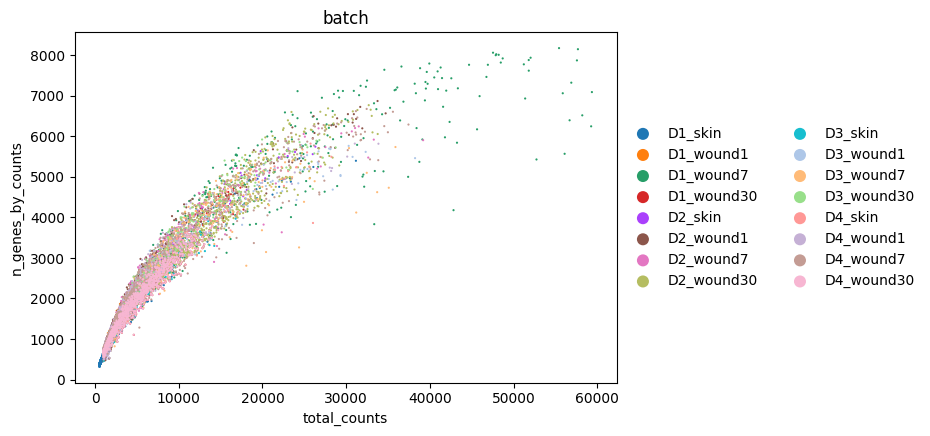

In [ ]:
sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts",
    color="batch"
)

In [ ]:
adata.shape

(12251, 10500)

### Save Final Dataset

In [ ]:
adata.write(save_path)